# Image resizing & color transformation to evaluate the difference in segmentation ability for SAM2

## Imports

In [1]:
import os
import gc
import cv2
import csv
# import clip
import json
import torch
import hydra
import shutil
import torchvision

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from PIL import Image, ImageDraw
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121
CUDA is available: True
Using device: cuda


## Predefined variables

In [3]:
LABEL_DIR = "../images/Alles_JSONs"

ALLES_DIR = "../images/Alles"

ORIG_DIR = "../images/original"
RESIZE_DIR = "../images/resized"
COLOR_DIR = "../images/grayscale"

OUT_DIR = "../outputs"
RESULTS_DIR = "../results"

IMAGE_CONDITIONS = {
    "original": ORIG_DIR,
    "resized": RESIZE_DIR,
    "grayscale": COLOR_DIR
}

LABEL_COLORS = {
    "Raam": [0.2, 0.6, 1.0],
    "Deur": [0.8, 0.2, 0.2],
    "Zonnepaneel": [1.0, 0.85, 0.0]
}

RESIZE_FORMAT = (512, 512)
COLOR = (0, 0, 0)

SAM2_CHECKPOINT_PATH = "../sam2/checkpoints/sam2.1_hiera_small.pt"
SAM2_MODEL_CONFIG_PATH = "configs/sam2.1/sam2.1_hiera_s.yaml"


os.makedirs(ORIG_DIR, exist_ok=True)
os.makedirs(RESIZE_DIR, exist_ok=True)
os.makedirs(COLOR_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [5]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize_config_module(config_module="sam2", version_base="1.2")

hydra.initialize_config_module()

## Structured folders

In [6]:
# RUN THIS CELL TO COPY ALL IMAGES AND JSON FILES TO THE ORIGINAL DIRECTORY
for json_file in os.listdir(LABEL_DIR):
    if json_file.endswith(".json"):
        json_path = os.path.join(LABEL_DIR, json_file)
        shutil.copy(json_path, ORIG_DIR)
        with open(json_path, "r") as f:
            data = json.load(f)
            image_filename = data["imagePath"]
            image_path = os.path.join(ALLES_DIR, image_filename)
            if os.path.exists(image_path):
                shutil.copy(image_path, ORIG_DIR)
            else:
                print(f"Image {image_filename} not found in {ALLES_DIR}")

## Image resizing

In [7]:
def resize_image(image, resize=RESIZE_FORMAT, color=COLOR):
    h, w = image.shape[:2]
    target_w, target_h = resize

    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized_img = cv2.resize(image, (new_w, new_h))

    pad_w = target_w - new_w
    pad_h = target_h - new_h

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    padded = cv2.copyMakeBorder(
        resized_img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color
    )

    return padded

In [8]:
def get_resize_transform_params(orig_w, orig_h, target_w=RESIZE_FORMAT[0], target_h=RESIZE_FORMAT[1]):
    scale = min(target_w / orig_w, target_h / orig_h)

    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    pad_left = (target_w - new_w) // 2
    pad_top = (target_h - new_h) // 2

    return scale, pad_left, pad_top

In [9]:
def transform_annotation(json_path, orig_w, orig_h, target_w=RESIZE_FORMAT[0], target_h=RESIZE_FORMAT[1]):
    with open(json_path, "r") as f:
        annotation = json.load(f)

    scale, pad_left, pad_top = get_resize_transform_params(orig_w, orig_h, target_w, target_h)

    new_shapes = []
    for shape in annotation["shapes"]:
        new_points = [[x*scale + pad_left, y*scale + pad_top] for x, y in shape["points"]]
        new_shape = shape.copy()
        new_shape["points"] = new_points
        new_shapes.append(new_shape)

    return {**annotation, "shapes": new_shapes, "imageWidth": target_w, "imageHeight": target_h, "imageData": None}

In [10]:
for file in os.listdir(ORIG_DIR):
    if file.endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(ORIG_DIR, file)
        img = cv2.imread(path)

        if img is None:
            try:
                pil_img = Image.open(path).convert("RGB")
                img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
                print(f"  NOTE: Successfully read {file} using PIL fallback.")
            except Exception as e:
                print(f"  SKIPPED (unreadable): {file} — {e}")
                continue

        resized = resize_image(img)

        cv2.imwrite(os.path.join(RESIZE_DIR, file), resized)

        json_file = os.path.splitext(file)[0] + ".json"
        json_path = os.path.join(ORIG_DIR, json_file)
        if os.path.exists(json_path):
            resized_annotation = transform_annotation(json_path, img.shape[1], img.shape[0])
            resized_annotation["imagePath"] = file
            with open(os.path.join(RESIZE_DIR, json_file), "w") as f:
                json.dump(resized_annotation, f, indent=2)
        else:
            print(f"  WARNING: No annotation found for {file}, skipping annotation transformation.")

print("Resizing complete!")

Resizing complete!


## Color transformation

In [11]:
def grayscale_image(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [12]:
for file in os.listdir(ORIG_DIR):
    if file.endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(ORIG_DIR, file)

        img = cv2.imread(path)

        if img is None:
            try:
                pil_img = Image.open(path).convert("RGB")
                img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
                print(f"  NOTE: Successfully read {file} using PIL fallback.")
            except Exception as e:
                print(f"  SKIPPED (unreadable): {file} — {e}")
                continue

        grayscale = grayscale_image(img)

        cv2.imwrite(os.path.join(COLOR_DIR, file), grayscale)

        json_file = os.path.splitext(file)[0] + ".json"
        json_path = os.path.join(ORIG_DIR, json_file)

        if os.path.exists(json_path):
            with open(json_path, "r") as f:
                annotation = json.load(f)

            annotation["imageData"] = None
            annotation["imagePath"] = file

            with open(os.path.join(COLOR_DIR, json_file), "w") as f:
                json.dump(annotation, f, indent=2)
        else:
            print(f"  WARNING: No annotation found for {file}, skipping annotation transformation.")

print("Color conversion complete!")

Color conversion complete!


In [ ]:
shape_types = set()
for file in os.listdir(ORIG_DIR):
    if file.endswith(".json"):
        json_path = os.path.join(ORIG_DIR, file)
        with open(json_path, "r") as f:
            data = json.load(f)
            for shape in data["shapes"]:
                shape_types.add(shape["shape_type"])
print("Unique shape types in annotations:", shape_types)

Unique shape types in annotations: {'rectangle', 'circle', 'polygon'}


## SAM 2

### Build model

In [14]:
sam2 = build_sam2(SAM2_MODEL_CONFIG_PATH, SAM2_CHECKPOINT_PATH, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=16,
    points_per_batch=128,
    pred_iou_thresh=0.75,
    stability_score_thresh=0.9,
    stability_score_offset=0.7,
    # crop_n_layers=0,
    box_nms_thresh=0.5,
    # crop_n_points_downscale_factor=2,
    min_mask_region_area=250,
    # use_m2m=True
)

### Functions

In [15]:
def polygon_to_mask(points, img_h, img_w):
    if len(points) < 3:
        print(f"  WARNING: Polygon only has {len(points)} point(s), skipped.")
        return np.zeros((img_h, img_w), dtype=bool)
    
    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).polygon([(x, y) for x, y in points], outline=1, fill=1)
    return np.array(mask, dtype=bool)

In [16]:
def circle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        print(f"  WARNING: Circle only has {len(points)} point(s), skipped.")
        return np.zeros((img_h, img_w), dtype=bool)
    
    cx, cy = points[0]
    rx, ry = points[1]
    radius = np.sqrt((rx-cx)**2 + (ry-cy)**2)

    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).ellipse([cx - radius, cy - radius, cx + radius, cy + radius], outline=1, fill=1)
    return np.array(mask, dtype=bool)

In [17]:
def rectangle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        print(f"  WARNING: Rectangle only has {len(points)} point(s), skipped.")
        return np.zeros((img_h, img_w), dtype=bool)
    
    x1, y1 = points[0]
    x2, y2 = points[1]

    x_min, x_max = min(x1, x2), max(x1, x2)
    y_min, y_max = min(y1, y2), max(y1, y2)

    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).rectangle([x_min, y_min, x_max, y_max], outline=1, fill=1)
    return np.array(mask, dtype=bool)

In [18]:
def load_gt_masks(json_path, img_h, img_w):
    with open(json_path, "r") as f:
        data = json.load(f)

    masks = []
    for s in data["shapes"]:
        shape_type = s["shape_type"]
        points = s["points"]

        if shape_type == "polygon":
            mask = polygon_to_mask(points, img_h, img_w)
        elif shape_type == "circle":
            mask = circle_to_mask(points, img_h, img_w)
        elif shape_type == "rectangle":
            mask = rectangle_to_mask(points, img_h, img_w)
        else:
            print(f"  WARNING: Unsupported shape type '{shape_type}' in {json_path}, skipping.")
            continue

        if mask.sum() == 0:
            print(f"  WARNING: Generated empty mask for shape type '{shape_type}' in {json_path}, skipping.")
            continue

        masks.append({"label": s["label"], "mask": mask})

    return masks

In [19]:
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

In [20]:
def mask_overlaps_annotation(sam_mask, gt_masks, threshold=0.3):
    best_iou = 0.0
    best_label = None

    for gt in gt_masks:
        iou = compute_iou(sam_mask, gt["mask"])
        if iou > best_iou:
            best_iou = iou
            best_label = gt["label"]
    
    if best_iou >= threshold:
        return True, best_label, best_iou
    
    return False, None, 0.0

In [21]:
def filter_masks_by_annotation(sam_masks, gt_masks, iou_threshold=0.3):
    filtered_masks = []
    
    for sam in sam_masks:
        keep, label, iou = mask_overlaps_annotation(sam["segmentation"], gt_masks, threshold=iou_threshold)
        if keep:
            filtered_masks.append({**sam, "label": label, "annot_iou": iou})

    return filtered_masks

In [22]:
def reproject_mask_to_original(mask, orig_w, orig_h, target_w=RESIZE_FORMAT[0], target_h=RESIZE_FORMAT[1]):
    scale, pad_left, pad_top = get_resize_transform_params(orig_w, orig_h, target_w, target_h)

    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    mask_cropped = mask[pad_top:pad_top+new_h, pad_left:pad_left+new_w]

    reprojected = cv2.resize(mask_cropped.astype(np.uint8), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    return reprojected.astype(bool)

In [23]:
def match_and_score(ref_masks, cmp_masks):
    results = []
    for ref in ref_masks:
        best_iou = 0.0

        for cmp in cmp_masks:
            if cmp["label"] != ref["label"]:
                continue
            iou = compute_iou(ref["segmentation"], cmp["segmentation"])
            if iou > best_iou:
                best_iou = iou
        results.append({"label": ref["label"], "annot_iou": best_iou})
        
    return results

In [24]:
def save_masked_visualization(image_rgb, filtered_masks, gt_masks, filename, condition, output_dir=OUT_DIR):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(image_rgb.astype(np.float32) / 255.0)
    gt_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)
    for gt in gt_masks:
        color = LABEL_COLORS.get(gt["label"], [0.5, 0.5, 0.5])
        gt_overlay[gt["mask"]] = list(color) + [0.4]
    axes[0].imshow(gt_overlay)
    axes[0].set_title(f"{condition.capitalize()} - Ground Truth", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(image_rgb.astype(np.float32) / 255.0)
    sam_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)
    for m in filtered_masks:
        color = LABEL_COLORS.get(m["label"], [0.5, 0.5, 0.5])
        sam_overlay[m["segmentation"]] = list(color) + [0.5]

        contours, _ = cv2.findContours(m["segmentation"].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(sam_overlay, contours, -1, list(color) + [1.0], thickness=1)

        ys, xs = np.where(m["segmentation"])
        if len(xs) > 0 and len(ys) > 0:
            center_x = int(xs.mean())
            center_y = int(ys.mean())
            axes[1].text(center_x, center_y, m["label"], color="white", fontsize=8, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.1",facecolor='black', alpha=0.5, edgecolor='none'))

    axes[1].imshow(sam_overlay)
    axes[1].set_title(f"{condition.capitalize()} - {len(filtered_masks)} SAM Masks", fontsize=12)
    axes[1].axis("off")

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS.get(label, [0.5, 0.5, 0.5])) for label in LABEL_COLORS
    ]
    axes[1].legend(legend_handles, LABEL_COLORS.keys(), loc="lower right", fontsize=8)

    save_path = os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_{condition}.png")
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.close()
    print(f"  Visualization saved to {save_path}")

### Evaluation loop

In [25]:
all_results = {}

for condition, img_dir in IMAGE_CONDITIONS.items():
    all_results[condition] = {}

In [ ]:
ORIG_IMAGES = [f for f in os.listdir(ORIG_DIR) if f.endswith((".jpg", ".jpeg", ".png"))]

for file in sorted(ORIG_IMAGES):
    json_orig = os.path.join(ORIG_DIR, os.path.splitext(file)[0] + ".json")
    if not os.path.exists(json_orig):
        print(f"\t  WARNING: No annotation found for {file} in original directory, skipping.")
        continue

    print(f"Processing {file}...")

    img_orig = Image.open(os.path.join(ORIG_DIR, file)).convert("RGB")
    orig_array = np.array(img_orig)
    img_h, img_w = orig_array.shape[:2]

    gt_orig = load_gt_masks(json_orig, img_h, img_w)

    sam_orig = mask_generator.generate(orig_array)
    filtered_orig = filter_masks_by_annotation(sam_orig, gt_orig)
    all_results["original"][file] = [
        {"label": m["label"], "annot_iou": m["annot_iou"]} for m in filtered_orig
    ]
    save_masked_visualization(orig_array, filtered_orig, gt_orig, file, "original", OUT_DIR)
    print(f"\t  Original: {len(filtered_orig)} SAM masks inside annotations.")


    img_resized = Image.open(os.path.join(RESIZE_DIR, file)).convert("RGB")
    resized_array = np.array(img_resized)
    sam_resized = mask_generator.generate(resized_array)

    json_resized = os.path.join(RESIZE_DIR, os.path.splitext(file)[0] + ".json")
    gt_resized = load_gt_masks(json_resized, RESIZE_FORMAT[0], RESIZE_FORMAT[1])
    filtered_resized = filter_masks_by_annotation(sam_resized, gt_resized)
    save_masked_visualization(resized_array, filtered_resized, gt_resized, file, "resized", OUT_DIR)

    for m in filtered_resized:
        m["segmentation"] = reproject_mask_to_original(m["segmentation"], orig_w=img_w, orig_h=img_h)

    scores_resized = match_and_score(filtered_orig, filtered_resized)
    all_results["resized"][file] = scores_resized
    print(f"\t  Resized: {len(filtered_resized)} SAM masks inside annotations.")


    img_gray = Image.open(os.path.join(COLOR_DIR, file)).convert("RGB")
    gray_array = np.array(img_gray)
    sam_gray = mask_generator.generate(gray_array)

    filtered_gray = filter_masks_by_annotation(sam_gray, gt_orig)
    save_masked_visualization(gray_array, filtered_gray, gt_orig, file, "grayscale", OUT_DIR)

    scores_gray = match_and_score(filtered_orig, filtered_gray)
    all_results["grayscale"][file] = scores_gray
    print(f"\t  Grayscale: {len(filtered_gray)} SAM masks inside annotations.")


    del sam_orig, sam_resized, sam_gray
    del filtered_orig, filtered_resized, filtered_gray
    del orig_array, resized_array, gray_array
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Processing image_10.jpg...
  Visualization saved to ../outputs\image_10_original.png
	  Original: 4 SAM masks inside annotations.
  Visualization saved to ../outputs\image_10_resized.png
	  Resized: 3 SAM masks inside annotations.
  Visualization saved to ../outputs\image_10_grayscale.png
	  Grayscale: 3 SAM masks inside annotations.
Processing image_103.jpg...
  Visualization saved to ../outputs\image_103_original.png
	  Original: 14 SAM masks inside annotations.
  Visualization saved to ../outputs\image_103_resized.png
	  Resized: 12 SAM masks inside annotations.
  Visualization saved to ../outputs\image_103_grayscale.png
	  Grayscale: 15 SAM masks inside annotations.
Processing image_104.jpg...
  Visualization saved to ../outputs\image_104_original.png
	  Original: 6 SAM masks inside annotations.
  Visualization saved to ../outputs\image_104_resized.png
	  Resized: 6 SAM masks inside annotations.
  Visualization saved to ../outputs\image_104_grayscale.png
	  Grayscale: 4 SAM masks i

In [27]:
with open(os.path.join(RESULTS_DIR, "sam2_results.csv"), "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Condition", "File", "Label", "IoU"])
    for condition, files in all_results.items():
        for file, scores in files.items():
            for score in scores:
                writer.writerow([condition, file, score["label"], round(float(score["annot_iou"]), 4)])

print(f"Evaluation complete! Results saved to {RESULTS_DIR}/sam2_results.csv")

Evaluation complete! Results saved to ../results/sam2_results.csv


## Analysis

In [4]:
df = pd.read_csv(os.path.join(RESULTS_DIR, "sam2_results.csv"))

df["Label"] = df["Label"].str.lower()
df["Condition"] = df["Condition"].str.lower()

print(df.head())
print(f"\nAmount of rows: {len(df)}")
print(f"Conditions: {df['Condition'].unique()}")
print(f"Labels: {df['Label'].unique()}")

  Condition           File        Label     IoU
0  original   image_10.jpg         raam  0.4485
1  original   image_10.jpg         raam  0.5822
2  original   image_10.jpg  zonnepaneel  0.8537
3  original   image_10.jpg         raam  0.5233
4  original  image_103.jpg         raam  0.7358

Amount of rows: 6840
Conditions: ['original' 'resized' 'grayscale']
Labels: ['raam' 'zonnepaneel' 'deur']


In [5]:
summary = df.groupby(["Condition", "Label"])["IoU"].agg(["mean", "std", "count"]).round(4)

print("Mean IoU per condition per label:")
print(summary)

summary.to_csv(os.path.join(RESULTS_DIR, "iou_summary.csv"))

Mean IoU per condition per label:
                         mean     std  count
Condition Label                             
grayscale deur         0.8186  0.3293    444
          raam         0.8543  0.2871   1734
          zonnepaneel  0.7304  0.3993    102
original  deur         0.6086  0.1788    444
          raam         0.5515  0.1719   1734
          zonnepaneel  0.7031  0.1736    102
resized   deur         0.7266  0.3556    444
          raam         0.6512  0.3812   1734
          zonnepaneel  0.4561  0.4296    102


In [6]:
pivot = df.groupby(["Condition", "Label"])["IoU"].mean().unstack("Condition").round(4)
pivot = pivot[["original", "resized", "grayscale"]]

print("Table for paper (mean IoU):")
print(pivot)

Table for paper (mean IoU):
Condition    original  resized  grayscale
Label                                    
deur           0.6086   0.7266     0.8186
raam           0.5515   0.6512     0.8543
zonnepaneel    0.7031   0.4561     0.7304


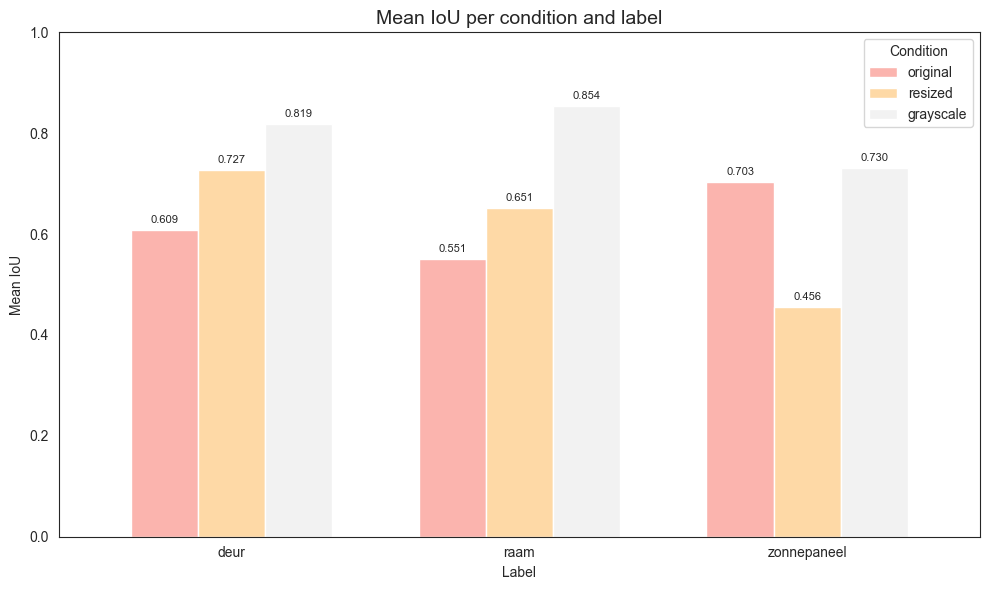

In [7]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, colormap="Pastel1", width=0.7)
ax.set_title("Mean IoU per condition and label", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Mean IoU")
ax.set_ylim(0, 1)
ax.legend(title="Condition")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.01, f"{height:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "iou_per_label.png"), dpi=150)
plt.show()

In [8]:
print("Statistical tests (Wilcoxon signed-rank, original vs condition):")

for condition in ["resized", "grayscale"]:
    orig = df[df["Condition"] == "original"].set_index(["File", "Label"])["IoU"]
    cmp = df[df["Condition"] == condition].set_index(["File", "Label"])["IoU"]

    common = orig.index.intersection(cmp.index)
    if len(common) < 5:
        print(f"  Not enough common samples for {condition} (n={len(common)}), test skipped.")
        continue

    stat, p = stats.wilcoxon(orig.loc[common].values, cmp.loc[common].values)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  Original vs {condition.capitalize()}: p-value = {p:.5f} ({sig})")

Statistical tests (Wilcoxon signed-rank, original vs condition):
  Original vs Resized: p-value = 0.00000 (significant)
  Original vs Grayscale: p-value = 0.00000 (significant)


In [9]:
print("Relative IoU drop vs. original (%):")

orig_mean = df[df["Condition"] == "original"].groupby("Label")["IoU"].mean()

for condition in ["resized", "grayscale"]:
    cmp_mean = df[df["Condition"] == condition].groupby("Label")["IoU"].mean()
    relative_drop = ((orig_mean - cmp_mean) / orig_mean * 100).round(2)
    print(f"\n     {condition}:")
    for label, pct in relative_drop.items():
        arrow = "▼" if pct < 0 else "▲"
        print(f"       {label}: {arrow} {abs(pct):.2f}%")

Relative IoU drop vs. original (%):

     resized:
       deur: ▼ 19.38%
       raam: ▼ 18.08%
       zonnepaneel: ▲ 35.13%

     grayscale:
       deur: ▼ 34.50%
       raam: ▼ 54.91%
       zonnepaneel: ▼ 3.87%


## Use of SAM 2 to generate masks (old)

### Build SAM 2 model

In [34]:
# sam2 = build_sam2(SAM2_MODEL_CONFIG_PATH, SAM2_CHECKPOINT_PATH, device=device, apply_postprocessing=False)

# mask_generator = SAM2AutomaticMaskGenerator(
#     model=sam2,
#     points_per_side=16,
#     points_per_batch=128,
#     pred_iou_thresh=0.75,
#     stability_score_thresh=0.9,
#     stability_score_offset=0.7,
#     # crop_n_layers=0,
#     box_nms_thresh=0.5,
#     # crop_n_points_downscale_factor=2,
#     min_mask_region_area=750,
#     # use_m2m=True
# )

### Show annotations function

In [35]:
# np.random.seed(3)

# def show_anns(anns, borders=True):
#     if len(anns) == 0:
#         return
#     sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
#     ax = plt.gca()
#     ax.set_autoscale_on(False)

#     img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
#     img[:, :, 3] = 0
#     for ann in sorted_anns:
#         m = ann['segmentation']
#         color_mask = np.concatenate([np.random.random(3), [0.5]])
#         img[m] = color_mask 
#         if borders:
#             contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 

#             # Try to smooth contours
#             contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
#             cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

#     ax.imshow(img)

### SAM 2 on original images

In [36]:
# for file in os.listdir(IMG_DIR)[:10]:
#     if file.endswith((".jpg", ".jpeg", ".png")):
#         path = os.path.join(IMG_DIR, file)
#         print(f"Processing {file}...")

#         image = Image.open(path).convert("RGB")
#         image = np.array(image)

#         masks = mask_generator.generate(image)

#         plt.figure(figsize=(20, 20))
#         plt.imshow(image)
#         show_anns(masks)
#         plt.axis('off')
#         plt.show()

# print("Mask generation complete!")

## ARCHIVE: Use of CLIP for automatic labeling of the masks
> this will not be used anymore

In [37]:
# clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

In [38]:
# with torch.no_grad():
#     text_tokens = clip.tokenize(TEXT_PROMPTS).to(device)
#     text_features = clip_model.encode_text(text_tokens)
#     text_features /= text_features.norm(dim=-1, keepdim=True)

In [39]:
# def extract_masked_crop(image, mask):
#     rows = np.any(mask, axis=1)
#     cols = np.any(mask, axis=0)
#     rmin, rmax = np.where(rows)[0][[0, -1]]
#     cmin, cmax = np.where(cols)[0][[0, -1]]

#     pad = 10
#     rmin = max(rmin - pad, 0)
#     rmax = min(rmax + pad, image.shape[0] - 1)
#     cmin = max(cmin - pad, 0)
#     cmax = min(cmax + pad, image.shape[1] - 1)

#     crop = image[rmin:rmax+1, cmin:cmax+1].copy()
#     mask_crop = mask[rmin:rmax+1, cmin:cmax+1]

#     crop[~mask_crop] = 0

#     return Image.fromarray(crop)

In [40]:
# def classify_mask_with_clip(image, mask):
#     crop_pil = extract_masked_crop(image, mask)

#     image_input = clip_preprocess(crop_pil).unsqueeze(0).to(device)

#     with torch.no_grad():
#         image_features = clip_model.encode_image(image_input)
#         image_features /= image_features.norm(dim=-1, keepdim=True)

#         similarities = (image_features @ text_features.T).squeeze(0)
#         probs = similarities.softmax(dim=-1).cpu().numpy()

#     best_idx = np.argmax(probs)
#     return FACADE_LABELS[best_idx], float(probs[best_idx])

In [41]:
# def label_all_masks_batched(image, masks):
#     crops = [clip_preprocess(extract_masked_crop(image, mask_dict["segmentation"])) for mask_dict in masks]
#     batch = torch.stack(crops).to(device)

#     with torch.no_grad():
#         image_features = clip_model.encode_image(batch)
#         image_features /= image_features.norm(dim=-1, keepdim=True)

#         similarities = image_features @ text_features.T
#         probs = similarities.softmax(dim=-1).cpu().numpy()

#     for i, mask_dict in enumerate(masks):
#         best_idx = np.argmax(probs[i])
#         best_score = float(probs[i][best_idx])
#         mask_dict["label"] = FACADE_LABELS[best_idx]
#         mask_dict["clip_score"] = best_score

#     return masks

In [42]:
# def show_labeled_anns(anns, borders=True):
#     if len(anns) == 0:
#         return

#     sorted_anns = sorted(anns, key=(lambda x: x["area"]), reverse=True)
#     ax = plt.gca()
#     ax.set_autoscale_on(False)

#     h, w = sorted_anns[0]["segmentation"].shape
#     overlay = np.zeros((h, w, 4))

#     for ann in sorted_anns:
#         m = ann["segmentation"]
#         label = ann.get("label", "unknown")
#         # score = ann.get("clip_score", 0.0)

#         base_color = LABEL_COLORS.get(label, [0.5, 0.5, 0.5])
#         color_mask = list(base_color) + [0.5]
#         overlay[m] = color_mask

#         if borders:
#             contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
#             contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
#             cv2.drawContours(overlay, contours, -1, (0, 0, 0, 0.75), thickness=1)

#         ys, xs = np.where(m)
#         cx, cy = int(xs.mean()), int(ys.mean())
#         ax.text(
#             cx, cy,
#             f"{label}",
#             color="white", 
#             fontsize=7,
#             ha="center", va="center",
#             bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.4, ec="none")
#         )

#     ax.imshow(overlay)

In [43]:
# def summarize_labels(masks):
#     summary = defaultdict(lambda: {"count": 0, "total_score": 0.0, "total_area": 0})

#     for m in masks:
#         label = m.get("label", "unknown")
#         summary[label]["count"] += 1
#         summary[label]["total_score"] += m.get("clip_score", 0.0)
#         summary[label]["total_area"] += m.get("area", 0)

#     return {
#         label: {
#             "count": data["count"],
#             "avg_score": data["total_score"] / data["count"] if data["count"] > 0 else 0.0,
#             "total_area": data["total_area"]
#         }
#         for label, data in summary.items()
#     }

In [44]:
# results = {}

# for condition_name, img_dir in IMAGE_CONDITIONS.items():
#     print("\n" + "="*50)
#     print(f"Processing condition: {condition_name}")
#     print("="*50)

#     results[condition_name] = {}

#     for file in os.listdir(img_dir)[:15]:
#         if file.endswith((".jpg", ".jpeg", ".png")):
#             path = os.path.join(img_dir, file)
#             print(f"  Processing {file}...")

#             image = Image.open(path).convert("RGB")
#             image_rgb = np.array(image)

#             if len(image_rgb.shape) == 2:  # Grayscale
#                 image_rgb = np.stack([image_rgb] * 3, axis=-1)

#             masks = mask_generator.generate(image_rgb)
#             print(f"    Found {len(masks)} masks")

#             masks = label_all_masks_batched(image_rgb, masks)

#             summary = summarize_labels(masks)
#             results[condition_name][file] = {
#                 "label_summary": summary,
#                 "num_masks": len(masks)
#             }

#             fig, axes = plt.subplots(1, 2, figsize=(20, 10))

#             axes[0].imshow(image_rgb.astype(np.float32) / 255.0)
#             axes[0].set_title(f"{condition_name} - Original")
#             axes[0].axis("off")

#             axes[1].imshow(image_rgb.astype(np.float32) / 255.0)
#             plt.sca(axes[1])
#             show_labeled_anns(masks)
#             axes[1].set_title(f"{condition_name} - Labeled Masks")
#             axes[1].axis("off")

#             save_path = os.path.join(OUTPUT_DIR, f"{os.path.splitext(file)[0]}_{condition_name}_labeled.png")
#             plt.savefig(save_path)
#             plt.close()
#             print(f"    Saved labeled visualization to {save_path}")

# print("\nProcessing complete! Results summary:")
# print(json.dumps(results, indent=2))